- Miguel Baños Baladrón
- Fiz Garrido Escudero

# Práctica 1: Clasificación

### Importaciones

In [ ]:
import os
import glob
import torch
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import torchvision.models as models
import torch.nn as nn
import torch.optim as optim

from torch.utils import data
from torch.utils.data import Subset
from torch.utils.data import DataLoader
from torchvision.io import read_image
from torchvision import transforms

# 1.- Creación de Dataset personalizado

In [ ]:
class ShipDataset(data.Dataset):
    def __init__(self, image_path, ship_csv, docked_csv, transform=None):
        super().__init__()
        # Buscamos todas las imágenes de la carpeta, sean .jpg o .png
        # Usamos sorted() para garantizar orden, ya que glob.glob no lo hace (evitamos data leakage)
        self.image_files = sorted(
            glob.glob(os.path.join(image_path, '*.jpg')) +
            glob.glob(os.path.join(image_path, '*.png'))
        )

        # Leer CSVs
        ship   = pd.read_csv(ship_csv,   sep=';', header=0)
        docked = pd.read_csv(docked_csv, sep=';', header=0)

        # Renombrar columnas por claridad y para poder unirlas usando filename
        ship.columns   = ['filename', 'ship_label']
        docked.columns = ['filename', 'docked_label']

        # Unimos los csv usando filename, conservando todas las imágenes de ship.csv (para estar atracado, debe haber barco)
        # Las imágenes sin etiqueta docked (no aparecen en docked.csv) reciben -1
        merged = ship.merge(docked, on='filename', how='left')
        merged['docked_label'] = merged['docked_label'].fillna(-1).astype(int)

        # Diccionario de etiquetas: filename -> [ship_label, docked_label]
        self.labels = {row['filename']: [row['ship_label'], row['docked_label']] for _, row in merged.iterrows()}

        # Transformaciones
        if transform:
            self.transform = transform
        else:
            self.transform = transforms.Compose([
                transforms.ToPILImage(),
                transforms.ToTensor()
            ])

    def __getitem__(self, index):
        image_path = self.image_files[index] # Ruta de la imagen en posición pedida ("index")
        image_name = os.path.splitext(os.path.basename(image_path))[0] # Extraemos nombre imagen
        image = read_image(image_path) # Devuelve un tensor [C, H, W]
        image = self.transform(image)    # Aplicamos transformaciones
        filename = os.path.basename(image_path)
        labels = torch.tensor(self.labels[filename], dtype=torch.float32)
        return image, labels, image_name

    def __len__(self):
        return len(self.image_files)

# 2.- Clasificación Ship/No-Ship

In [43]:
IMAGE_PATH = r"C:\Users\Pc\Desktop\Uni\Tercero\segundo_cuatri\VCA\VCA\P1-Material\images"
SHIP_CSV   = r"C:\Users\Pc\Desktop\Uni\Tercero\segundo_cuatri\VCA\VCA\P1-Material\ship.csv"
DOCKED_CSV = r"C:\Users\Pc\Desktop\Uni\Tercero\segundo_cuatri\VCA\VCA\P1-Material\docked.csv"

### Transforms

Se definen tres transforms:
- **`base_transform`**: normalización estándar ImageNet, usada en entrenamiento (sin aug) y siempre en test.
- **`aug_transform`**: añade aumentos específicos del dominio portuario (flips, jitter de iluminación, rotación).
- **`display_transform`**: solo resize, **sin normalización**, para poder visualizar las imágenes de test con matplotlib.

In [44]:
# Transform base: usado en entrenamiento sin aug y siempre en test/evaluación
base_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Transform con Data Augmentation específico del dominio portuario:
# - HorizontalFlip: barcos pueden aparecer en cualquier orientación horizontal
# - VerticalFlip:   reflejos en el agua generan simetría vertical
# - ColorJitter:    variaciones de iluminación (día/noche, cámaras distintas)
# - Rotation:       diferentes ángulos de cámara / inclinación del mástil
aug_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Transform de visualización: solo resize, SIN normalización
# Necesario para mostrar imágenes legibles en matplotlib
display_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

### División del dataset — Split por escena

El diagnóstico de leakage reveló que el split aleatorio mezcla imágenes de
las mismas cámaras en train y test. El modelo aprendería a reconocer escenarios
en lugar de detectar barcos.

La solución es dividir por **escena** (identificada por el prefijo del nombre
de fichero, que codifica la cámara): todas las imágenes de una cámara van
íntegramente a train o a test, nunca a ambos.

Consecuencia esperada: el accuracy bajará respecto al split aleatorio —
y eso es correcto, porque ahora mide generalización real a escenas nuevas.

In [45]:
# Dataset auxiliar (sin transform) solo para obtener etiquetas y calcular índices
dataset_ref = ShipDataset(IMAGE_PATH, SHIP_CSV, DOCKED_CSV)

filenames   = dataset_ref.image_files
ship_labels = [dataset_ref.labels[os.path.basename(f)][0] for f in filenames]

In [46]:
import collections, random

# ── 1. Agrupar imágenes por escena (prefijo del nombre de fichero) ──────────
# El prefijo (ej. 'ns-0', 's-01') identifica la cámara/localización.
# Usamos los primeros 4 caracteres como proxy de escena.

scene_to_files = collections.defaultdict(list)
for f in filenames:
    prefix = os.path.splitext(os.path.basename(f))[0][:4]
    scene_to_files[prefix].append(f)

scenes = sorted(scene_to_files.keys())
print(f"Escenas (cámaras) únicas: {len(scenes)}")
for s in scenes:
    imgs = scene_to_files[s]
    labels_s = [dataset_ref.labels[os.path.basename(f)][0] for f in imgs]
    print(f"  '{s}': {len(imgs)} imgs  "
          f"(ship={sum(labels_s)}, no-ship={sum(1 for l in labels_s if l==0)})")

Escenas (cámaras) únicas: 21
  'ns-0': 99 imgs  (ship=0, no-ship=99)
  'ns-1': 11 imgs  (ship=0, no-ship=11)
  's-00': 9 imgs  (ship=9, no-ship=0)
  's-01': 10 imgs  (ship=10, no-ship=0)
  's-02': 10 imgs  (ship=10, no-ship=0)
  's-03': 10 imgs  (ship=10, no-ship=0)
  's-04': 10 imgs  (ship=10, no-ship=0)
  's-05': 10 imgs  (ship=10, no-ship=0)
  's-06': 10 imgs  (ship=10, no-ship=0)
  's-07': 10 imgs  (ship=10, no-ship=0)
  's-08': 10 imgs  (ship=10, no-ship=0)
  's-09': 10 imgs  (ship=10, no-ship=0)
  's-10': 10 imgs  (ship=10, no-ship=0)
  's-11': 10 imgs  (ship=10, no-ship=0)
  's-12': 10 imgs  (ship=10, no-ship=0)
  's-13': 10 imgs  (ship=10, no-ship=0)
  's-14': 10 imgs  (ship=10, no-ship=0)
  's-15': 10 imgs  (ship=10, no-ship=0)
  's-16': 10 imgs  (ship=10, no-ship=0)
  's-17': 10 imgs  (ship=10, no-ship=0)
  's-18': 5 imgs  (ship=5, no-ship=0)


In [47]:
# Split estratificado por escena:
# separamos escenas ship-only, no-ship-only y mixtas,
# y repartimos cada grupo proporcionalmente entre train y test

scenes_ship    = [s for s in scenes if all(
    dataset_ref.labels[os.path.basename(f)][0] == 1
    for f in scene_to_files[s])]

scenes_noship  = [s for s in scenes if all(
    dataset_ref.labels[os.path.basename(f)][0] == 0
    for f in scene_to_files[s])]

scenes_mixed   = [s for s in scenes
                  if s not in scenes_ship and s not in scenes_noship]

print(f"Escenas 100% ship:    {len(scenes_ship)}  → {scenes_ship}")
print(f"Escenas 100% no-ship: {len(scenes_noship)} → {scenes_noship}")
print(f"Escenas mixtas:       {len(scenes_mixed)}  → {scenes_mixed}")

random.seed(42)
def split_group(group, test_ratio=0.20):
    g = group.copy()
    random.shuffle(g)
    n_test = max(1, round(len(g) * test_ratio))
    return g[n_test:], g[:n_test]   # train, test

train_s_scenes,  test_s_scenes  = split_group(scenes_ship)
train_ns_scenes, test_ns_scenes = split_group(scenes_noship)
train_m_scenes,  test_m_scenes  = split_group(scenes_mixed)

train_scenes = train_s_scenes + train_ns_scenes + train_m_scenes
test_scenes  = test_s_scenes  + test_ns_scenes  + test_m_scenes

train_files  = [f for s in train_scenes for f in scene_to_files[s]]
test_files   = [f for s in test_scenes  for f in scene_to_files[s]]
train_labels = [dataset_ref.labels[os.path.basename(f)][0] for f in train_files]
test_labels  = [dataset_ref.labels[os.path.basename(f)][0] for f in test_files]

print(f"\nEscenas train: {len(train_scenes)} | Escenas test: {len(test_scenes)}")
print(f"Imágenes train: {len(train_files)} | Imágenes test: {len(test_files)}")
print(f"  Train ship={sum(train_labels)} / no-ship={sum(1 for l in train_labels if l==0)}")
print(f"  Test  ship={sum(test_labels)}  / no-ship={sum(1 for l in test_labels  if l==0)}")

# Verificación sin leakage
train_pfx = {os.path.splitext(os.path.basename(f))[0][:4] for f in train_files}
test_pfx  = {os.path.splitext(os.path.basename(f))[0][:4] for f in test_files}
assert len(train_pfx & test_pfx) == 0, "ERROR: hay escenas compartidas"
print("\nVerificación OK: ninguna escena aparece en train Y test.")

Escenas 100% ship:    19  → ['s-00', 's-01', 's-02', 's-03', 's-04', 's-05', 's-06', 's-07', 's-08', 's-09', 's-10', 's-11', 's-12', 's-13', 's-14', 's-15', 's-16', 's-17', 's-18']
Escenas 100% no-ship: 2 → ['ns-0', 'ns-1']
Escenas mixtas:       0  → []

Escenas train: 16 | Escenas test: 5
Imágenes train: 243 | Imágenes test: 51
  Train ship=144 / no-ship=99
  Test  ship=40  / no-ship=11

Verificación OK: ninguna escena aparece en train Y test.


In [48]:
# ── 3. Convertir rutas a índices (igual que antes) ─────────────────────────
file_to_idx = {f: i for i, f in enumerate(filenames)}

train_idx = [file_to_idx[f] for f in train_files]
test_idx  = [file_to_idx[f] for f in test_files]

In [49]:
# Tres instancias del dataset con sus transforms
dataset_base    = ShipDataset(IMAGE_PATH, SHIP_CSV, DOCKED_CSV, transform=base_transform)
dataset_aug     = ShipDataset(IMAGE_PATH, SHIP_CSV, DOCKED_CSV, transform=aug_transform)
dataset_display = ShipDataset(IMAGE_PATH, SHIP_CSV, DOCKED_CSV, transform=display_transform)

train_dataset_base = Subset(dataset_base,    train_idx)
train_dataset_aug  = Subset(dataset_aug,     train_idx)
test_dataset       = Subset(dataset_base,    test_idx)   # test siempre sin aug
test_dataset_disp  = Subset(dataset_display, test_idx)   # para visualización

### DataLoaders

In [50]:
BATCH_SIZE = 16   # Reducido: con ~200 imgs el dataset es pequeño

def make_loaders(train_dataset):
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
    test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
    return train_loader, test_loader

# 3.- Modelo, entrenamiento y evaluación

In [51]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando: {device}")

def build_model(pretrained=True, freeze_backbone=True):
    """ResNet-18 con la última capa sustituida para clasificación binaria.

    freeze_backbone=True  -> solo se entrena la capa fc (recomendado con datasets pequeños).
                             Evita overfitting: pasa de ~11M parámetros entrenables a ~513.
    freeze_backbone=False -> fine-tuning completo de toda la red.
    """
    weights = models.ResNet18_Weights.IMAGENET1K_V1 if pretrained else None
    model = models.resnet18(weights=weights)

    if freeze_backbone:
        for param in model.parameters():
            param.requires_grad = False   # congela todo

    model.fc = nn.Linear(model.fc.in_features, 1)  # esta capa sí es entrenable
    return model.to(device)

Usando: cpu


In [52]:
def train(model, train_loader, epochs=15):
    criterion = nn.BCEWithLogitsLoss()
    # weight_decay añade regularización L2, penaliza pesos grandes
    optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

    history = {'loss': [], 'acc': []}

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total   = 0

        for images, labels, _ in train_loader:
            images = images.to(device)
            labels = labels[:, 0].unsqueeze(1).to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss    = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            preds    = torch.sigmoid(outputs) > 0.5
            correct += (preds == labels.bool()).sum().item()
            total   += labels.size(0)

        epoch_loss = running_loss / len(train_loader)
        epoch_acc  = correct / total
        history['loss'].append(epoch_loss)
        history['acc'].append(epoch_acc)

        print(f"Epoch {epoch+1:02d}/{epochs} | "
              f"Loss: {epoch_loss:.4f} | "
              f"Train Acc: {epoch_acc:.4f}")

    return model, history

In [53]:
def evaluate(model, test_loader, label_idx=0, history=None):
    """Evaluación cuantitativa + gráficas de entrenamiento (si se pasa history).
    label_idx=0 -> ship/no-ship | label_idx=1 -> docked/undocked
    """
    model.eval()
    correct = 0
    total   = 0

    with torch.no_grad():
        for images, labels, _ in test_loader:
            images = images.to(device)
            labels = labels[:, label_idx].unsqueeze(1).to(device)
            outputs = model(images)
            preds   = torch.sigmoid(outputs) > 0.5
            correct += (preds == labels.bool()).sum().item()
            total   += labels.size(0)

    acc = correct / total
    print(f"Test Accuracy: {acc:.4f} ({correct}/{total})")

    if history is not None:
        epochs = range(1, len(history['loss']) + 1)
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

        ax1.plot(epochs, history['loss'], 'o-', label='Train Loss')
        ax1.set_title('Loss por época')
        ax1.set_xlabel('Época')
        ax1.set_ylabel('BCE Loss')
        ax1.grid(True)
        ax1.legend()

        ax2.plot(epochs, history['acc'], 'o-', color='tab:green', label='Train Acc')
        ax2.axhline(y=acc, color='tab:red', linestyle='--', label=f'Test Acc ({acc:.4f})')
        ax2.set_title('Accuracy por época')
        ax2.set_xlabel('Época')
        ax2.set_ylabel('Accuracy')
        ax2.set_ylim(0, 1.05)
        ax2.grid(True)
        ax2.legend()

        plt.tight_layout()
        plt.show()

    return acc

In [54]:
def evaluate_qualitative(model, test_loader_norm, test_dataset_disp,
                         label_idx=0, max_errors=20):
    """Evaluación cualitativa: muestra los errores del clasificador.

    Para cada imagen mal clasificada en el test set se muestra:
      - La imagen original (sin normalización, legible para el ojo humano)
      - El tipo de error con borde de color:
          ROJO    = Falso Positivo (predijo ship=1, ground truth=0)
          NARANJA = Falso Negativo (predijo ship=0, ground truth=1)
      - El nombre de archivo y la confianza del modelo (prob. sigmoid)

    Parámetros
    ----------
    model             : modelo entrenado en eval mode
    test_loader_norm  : DataLoader con imágenes normalizadas (para inferencia)
    test_dataset_disp : Subset con display_transform (para visualización)
    label_idx         : 0=ship, 1=docked
    max_errors        : número máximo de errores a mostrar
    """
    model.eval()

    errors = []   # lista de (img_display, gt, pred, confidence, name)

    with torch.no_grad():
        for images, labels, names in test_loader_norm:
            images_gpu = images.to(device)
            labels_gpu = labels[:, label_idx].to(device)  # [B]

            logits = model(images_gpu).squeeze(1)          # [B]
            probs  = torch.sigmoid(logits)                 # [B]
            preds  = (probs > 0.5).long()                  # [B]
            gts    = labels_gpu.long()                     # [B]

            for i in range(len(names)):
                if preds[i] != gts[i]:
                    errors.append({
                        'name':       names[i],
                        'gt':         gts[i].item(),
                        'pred':       preds[i].item(),
                        'confidence': probs[i].item(),
                    })

    if not errors:
        print("No hay errores en el test set.")
        return

    # Mapa nombre -> imagen de display (sin normalización)
    disp_map = {}
    for img_disp, _, name in test_dataset_disp:
        disp_map[name] = img_disp  # Tensor [C, H, W] en [0,1]

    # --- Separar FP y FN ---
    fp = [e for e in errors if e['pred'] == 1 and e['gt'] == 0]
    fn = [e for e in errors if e['pred'] == 0 and e['gt'] == 1]

    print(f"\n{'='*55}")
    print(f" ERRORES DEL CLASIFICADOR ({label_idx==0 and 'Ship/No-ship' or 'Docked/Undocked'})")
    print(f"{'='*55}")
    print(f" Total errores : {len(errors)} / {len(test_dataset_disp)}")
    print(f" Falsos Positivos (FP) — predijo ship, era no-ship : {len(fp)}")
    print(f" Falsos Negativos (FN) — predijo no-ship, era ship : {len(fn)}")
    print(f"{'='*55}\n")

    errors_to_show = errors[:max_errors]
    n = len(errors_to_show)
    ncols = min(5, n)
    nrows = (n + ncols - 1) // ncols

    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 3.2, nrows * 3.2))
    axes = axes.flatten() if n > 1 else [axes]

    for ax, err in zip(axes, errors_to_show):
        img = disp_map[err['name']].permute(1, 2, 0).numpy()  # [H,W,C]
        ax.imshow(img)
        ax.axis('off')

        # Color del borde según tipo de error
        color  = 'red' if err['pred'] == 1 else 'darkorange'
        errtype = 'FP' if err['pred'] == 1 else 'FN'
        label_str = ('ship' if err['gt'] == 1 else 'no-ship')

        for spine in ax.spines.values():
            spine.set_edgecolor(color)
            spine.set_linewidth(4)
            spine.set_visible(True)

        conf = err['confidence']
        ax.set_title(
            f"{errtype} | gt={label_str}\n"
            f"conf={conf:.2f} | {err['name'][:18]}",
            fontsize=8, color=color, pad=3
        )

    # Ocultar ejes sobrantes
    for ax in axes[n:]:
        ax.set_visible(False)

    label_name = 'Ship/No-ship' if label_idx == 0 else 'Docked/Undocked'
    fig.suptitle(
        f"Errores de clasificación — {label_name}\n"
        f"[rojo] FP = predijo ship pero era no-ship   |   "
        f"[naranja] FN = predijo no-ship pero era ship",
        fontsize=10, y=1.01
    )
    plt.tight_layout()
    plt.show()

    return errors

In [61]:
# ═══════════════════════════════════════════════════════
# EXPERIMENTO A — Desde cero, sin Data Augmentation
# ═══════════════════════════════════════════════════════
print("=== EXPERIMENTO A (desde cero, sin augmentation) ===")
train_loader_base, test_loader = make_loaders(train_dataset_base)
model_a = build_model(pretrained=False, freeze_backbone=False)
model_a, history_a = train(model_a, train_loader_base, epochs=15)

=== EXPERIMENTO A (desde cero, sin augmentation) ===
Epoch 01/15 | Loss: 0.5937 | Train Acc: 0.6955
Epoch 02/15 | Loss: 0.4023 | Train Acc: 0.8066
Epoch 03/15 | Loss: 0.3929 | Train Acc: 0.8313
Epoch 04/15 | Loss: 0.3253 | Train Acc: 0.8601
Epoch 05/15 | Loss: 0.2267 | Train Acc: 0.8971
Epoch 06/15 | Loss: 0.2189 | Train Acc: 0.9095
Epoch 07/15 | Loss: 0.1544 | Train Acc: 0.9465
Epoch 08/15 | Loss: 0.1628 | Train Acc: 0.9547
Epoch 09/15 | Loss: 0.2159 | Train Acc: 0.8930
Epoch 10/15 | Loss: 0.1594 | Train Acc: 0.9300
Epoch 11/15 | Loss: 0.1609 | Train Acc: 0.9465
Epoch 12/15 | Loss: 0.1354 | Train Acc: 0.9506
Epoch 13/15 | Loss: 0.2599 | Train Acc: 0.9465
Epoch 14/15 | Loss: 0.2920 | Train Acc: 0.8765
Epoch 15/15 | Loss: 0.2246 | Train Acc: 0.9547


--- Evaluación cuantitativa ---
Test Accuracy: 0.6863 (35/51)


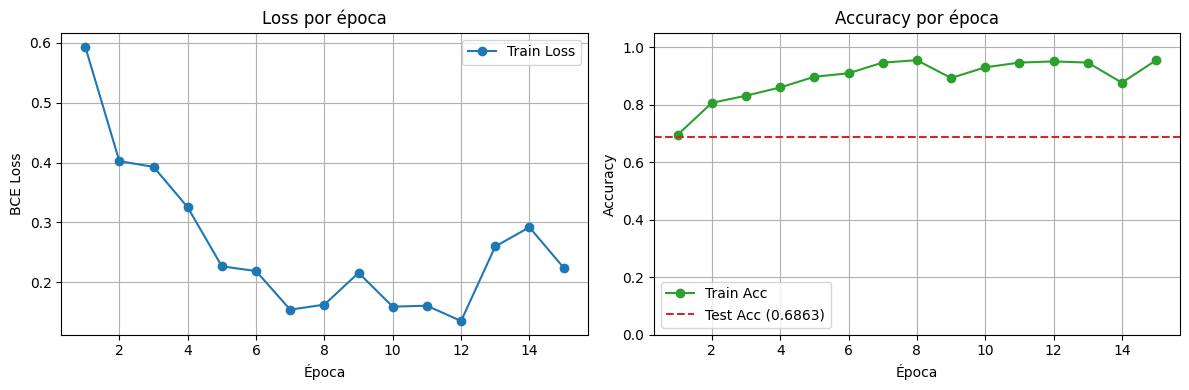


--- Evaluación cualitativa ---

 ERRORES DEL CLASIFICADOR (Ship/No-ship)
 Total errores : 16 / 51
 Falsos Positivos (FP) — predijo ship, era no-ship : 4
 Falsos Negativos (FN) — predijo no-ship, era ship : 12



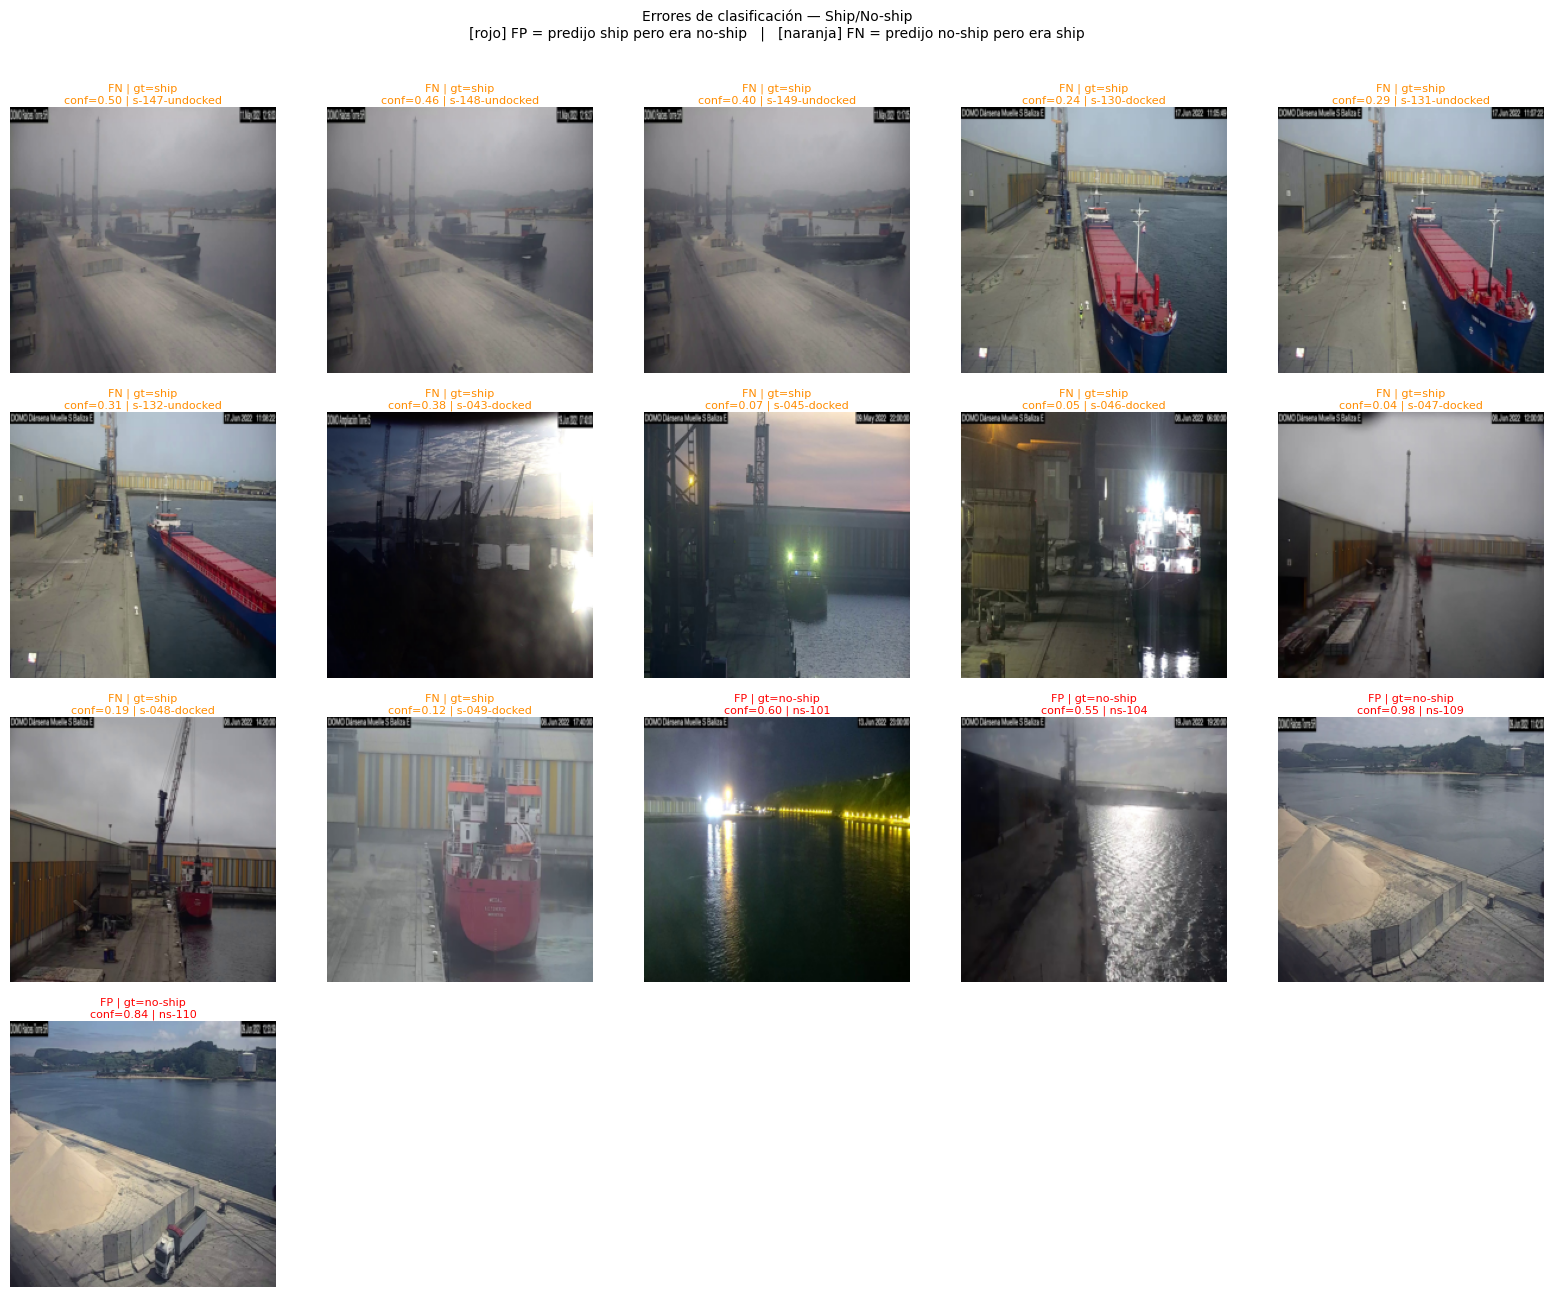

In [62]:
print("--- Evaluación cuantitativa ---")
acc_a = evaluate(model_a, test_loader, history=history_a)

print("\n--- Evaluación cualitativa ---")
errors_a = evaluate_qualitative(
    model_a,
    test_loader_norm=test_loader,
    test_dataset_disp=test_dataset_disp
)

## Experimento C — Preentrenado sin augmentation (sin Data Augmentation)

In [55]:
print("=== BASELINE (sin augmentation) ===")
train_loader_base, test_loader = make_loaders(train_dataset_base)
model_base = build_model(pretrained=True)
model_base, history_base = train(model_base, train_loader_base, epochs=15)

=== BASELINE (sin augmentation) ===
Epoch 01/15 | Loss: 0.7491 | Train Acc: 0.5309
Epoch 02/15 | Loss: 0.5562 | Train Acc: 0.6914
Epoch 03/15 | Loss: 0.4681 | Train Acc: 0.8189
Epoch 04/15 | Loss: 0.4147 | Train Acc: 0.8230
Epoch 05/15 | Loss: 0.3635 | Train Acc: 0.9218
Epoch 06/15 | Loss: 0.3395 | Train Acc: 0.8971
Epoch 07/15 | Loss: 0.3605 | Train Acc: 0.9053
Epoch 08/15 | Loss: 0.3139 | Train Acc: 0.9177
Epoch 09/15 | Loss: 0.3273 | Train Acc: 0.9218
Epoch 10/15 | Loss: 0.2970 | Train Acc: 0.9136
Epoch 11/15 | Loss: 0.2862 | Train Acc: 0.9136
Epoch 12/15 | Loss: 0.2349 | Train Acc: 0.9547
Epoch 13/15 | Loss: 0.2392 | Train Acc: 0.9465
Epoch 14/15 | Loss: 0.2175 | Train Acc: 0.9588
Epoch 15/15 | Loss: 0.2184 | Train Acc: 0.9383


--- Evaluación cuantitativa ---
Test Accuracy: 0.8627 (44/51)


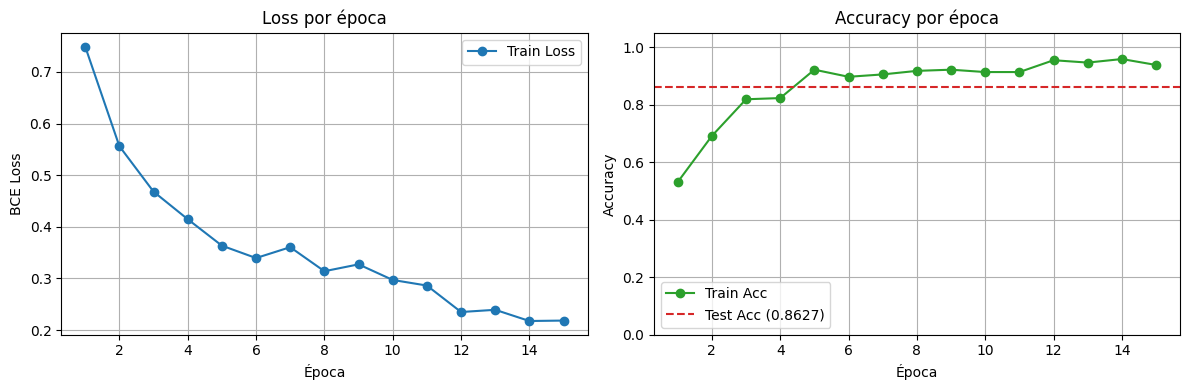


--- Evaluación cualitativa ---

 ERRORES DEL CLASIFICADOR (Ship/No-ship)
 Total errores : 7 / 51
 Falsos Positivos (FP) — predijo ship, era no-ship : 5
 Falsos Negativos (FN) — predijo no-ship, era ship : 2



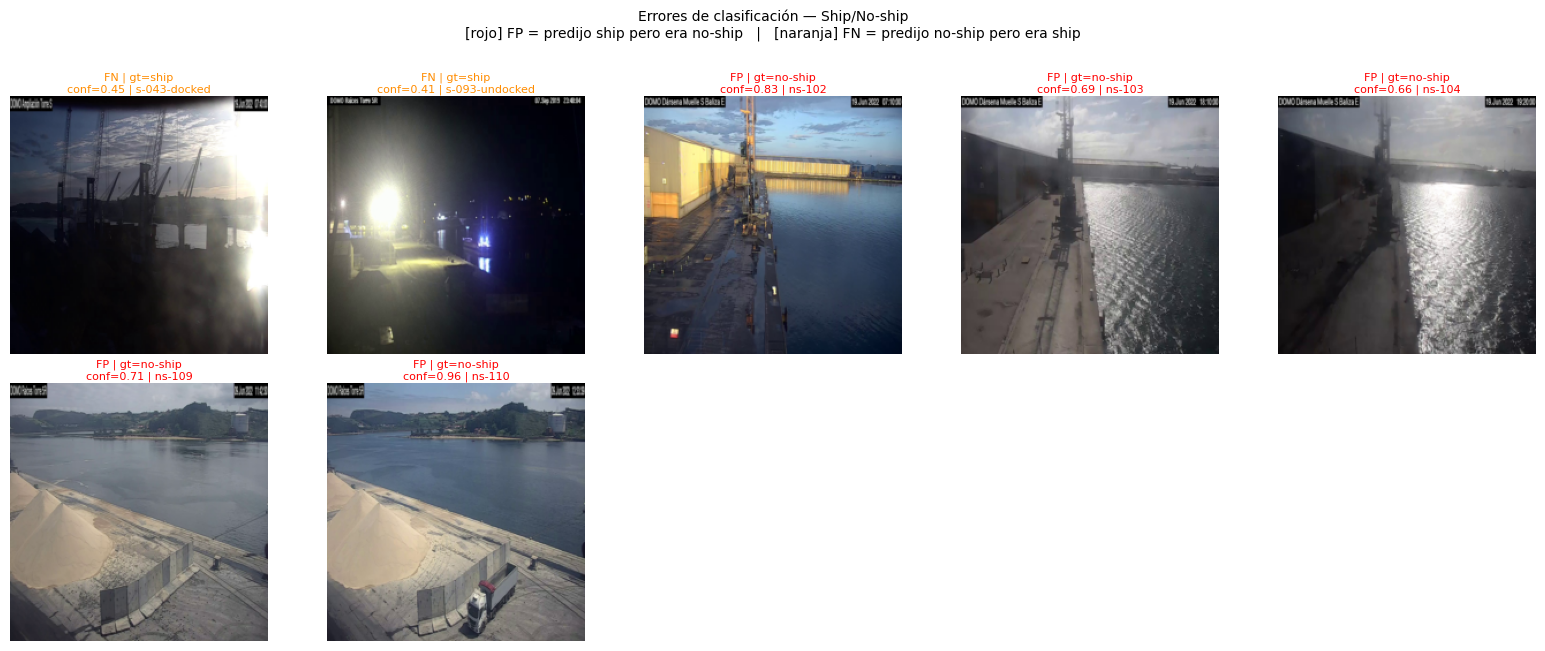

In [56]:
print("--- Evaluación cuantitativa ---")
acc_base = evaluate(model_base, test_loader, history=history_base)

print("\n--- Evaluación cualitativa ---")
errors_base = evaluate_qualitative(
    model_base,
    test_loader_norm=test_loader,
    test_dataset_disp=test_dataset_disp
)

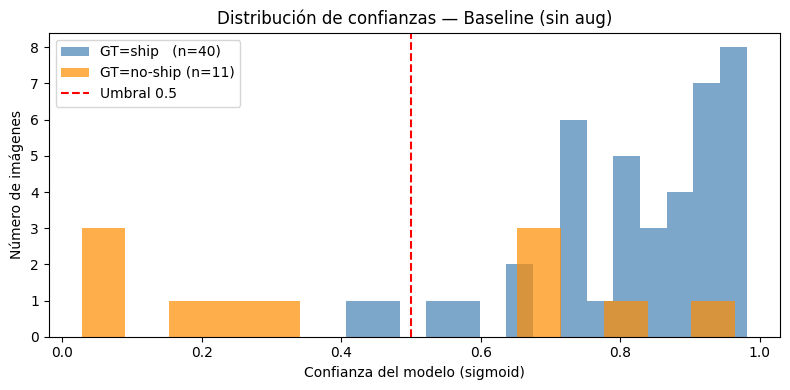

Confianza media GT=ship:    0.820
Confianza media GT=no-ship: 0.433
Predicciones con confianza >0.9: 20/51


In [57]:
# ── DIAGNÓSTICO 1: Distribución de confianzas ──────────────────────────────
# Si el modelo dice >0.95 en casi todo, es sospechoso (demasiado seguro)
# Si las confianzas están repartidas, el modelo es más honesto

def plot_confidence_distribution(model, test_loader, title="Baseline"):
    model.eval()
    all_probs  = []
    all_labels = []

    with torch.no_grad():
        for images, labels, _ in test_loader:
            images = images.to(device)
            logits = model(images).squeeze(1)
            probs  = torch.sigmoid(logits).cpu().numpy()
            gts    = labels[:, 0].numpy()
            all_probs.extend(probs)
            all_labels.extend(gts)

    probs  = [p for p in all_probs]
    labels = [int(l) for l in all_labels]

    ship_probs    = [p for p, l in zip(probs, labels) if l == 1]
    noship_probs  = [p for p, l in zip(probs, labels) if l == 0]

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.hist(ship_probs,   bins=15, alpha=0.7, color='steelblue',  label=f'GT=ship   (n={len(ship_probs)})')
    ax.hist(noship_probs, bins=15, alpha=0.7, color='darkorange', label=f'GT=no-ship (n={len(noship_probs)})')
    ax.axvline(0.5, color='red', linestyle='--', label='Umbral 0.5')
    ax.set_xlabel('Confianza del modelo (sigmoid)')
    ax.set_ylabel('Número de imágenes')
    ax.set_title(f'Distribución de confianzas — {title}')
    ax.legend()
    plt.tight_layout()
    plt.show()

    print(f"Confianza media GT=ship:    {sum(ship_probs)/len(ship_probs):.3f}")
    print(f"Confianza media GT=no-ship: {sum(noship_probs)/len(noship_probs):.3f}")
    print(f"Predicciones con confianza >0.9: {sum(1 for p in probs if p>0.9 or p<0.1)}/{len(probs)}")

plot_confidence_distribution(model_base, test_loader, title="Baseline (sin aug)")

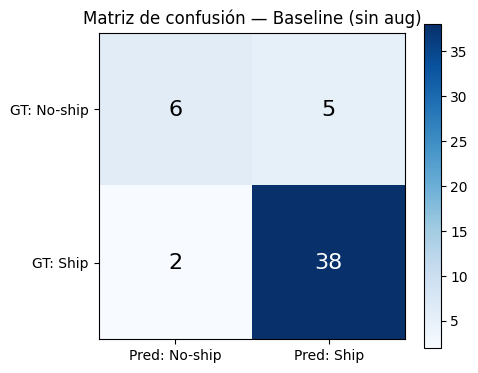

              precision    recall  f1-score   support

     No-ship       0.75      0.55      0.63        11
        Ship       0.88      0.95      0.92        40

    accuracy                           0.86        51
   macro avg       0.82      0.75      0.77        51
weighted avg       0.85      0.86      0.85        51

Precisión (ship): 0.884  |  Recall (ship): 0.950
TP=38  TN=6  FP=5  FN=2


In [58]:
# ── DIAGNÓSTICO 2: Matriz de confusión ─────────────────────────────────────
# Con solo 2 errores y 59 muestras: muestra exactamente dónde falla
# y la proporción real de TP/TN/FP/FN

from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

def plot_confusion_matrix(model, test_loader, title="Baseline"):
    model.eval()
    all_preds  = []
    all_labels = []

    with torch.no_grad():
        for images, labels, _ in test_loader:
            images = images.to(device)
            logits = model(images).squeeze(1)
            preds  = (torch.sigmoid(logits) > 0.5).long().cpu().numpy()
            gts    = labels[:, 0].long().numpy()
            all_preds.extend(preds)
            all_labels.extend(gts)

    cm = confusion_matrix(all_labels, all_preds)
    tn, fp, fn, tp = cm.ravel()

    fig, ax = plt.subplots(figsize=(5, 4))
    im = ax.imshow(cm, cmap='Blues')
    ax.set_xticks([0, 1]); ax.set_xticklabels(['Pred: No-ship', 'Pred: Ship'])
    ax.set_yticks([0, 1]); ax.set_yticklabels(['GT: No-ship', 'GT: Ship'])
    for i in range(2):
        for j in range(2):
            ax.text(j, i, cm[i, j], ha='center', va='center',
                    fontsize=16, color='white' if cm[i, j] > cm.max()/2 else 'black')
    ax.set_title(f'Matriz de confusión — {title}')
    plt.colorbar(im, ax=ax)
    plt.tight_layout()
    plt.show()

    print(classification_report(all_labels, all_preds,
                                 target_names=['No-ship', 'Ship']))
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall    = tp / (tp + fn) if (tp + fn) > 0 else 0
    print(f"Precisión (ship): {precision:.3f}  |  Recall (ship): {recall:.3f}")
    print(f"TP={tp}  TN={tn}  FP={fp}  FN={fn}")

plot_confusion_matrix(model_base, test_loader, title="Baseline (sin aug)")

In [59]:
# ── DIAGNÓSTICO 3: ¿Es el test realmente difícil? ──────────────────────────
# Compara train acc final vs test acc para detectar overfitting/underfitting
# y muestra el intervalo de confianza de Wilson para el test acc
# (con n=59, el intervalo es amplio — esto es clave para el informe)

import scipy.stats as stats

def confidence_interval_wilson(acc, n, alpha=0.05):
    """Intervalo de confianza de Wilson para una proporción."""
    z = stats.norm.ppf(1 - alpha / 2)
    p = acc
    denom = 1 + z**2 / n
    center = (p + z**2 / (2 * n)) / denom
    margin = (z * (p * (1 - p) / n + z**2 / (4 * n**2)) ** 0.5) / denom
    return center - margin, center + margin

n_test    = 59
acc_test  = 57 / 59
acc_train_final = history_base['acc'][-1]

lo, hi = confidence_interval_wilson(acc_test, n_test)

print("=" * 50)
print(" ANÁLISIS DE GENERALIZACIÓN")
print("=" * 50)
print(f" Train acc (época 15) : {acc_train_final:.4f}")
print(f" Test  acc            : {acc_test:.4f}  ({int(acc_test*n_test)}/{n_test})")
print(f" Diferencia           : {acc_test - acc_train_final:+.4f}")
print(f" IC 95% Wilson        : [{lo:.3f}, {hi:.3f}]")
print()
print(" Interpretación:")
if acc_test > acc_train_final:
    print("  · Test > Train → NO hay overfitting. El modelo generaliza bien.")
    print("  · Posible causa: backbone congelado (solo 513 params entrenables),")
    print("    ResNet-18+ImageNet ya extrae features muy discriminativas.")
else:
    print("  · Train > Test → Señal de overfitting.")
print(f"  · Con n={n_test}, el IC es [{lo:.3f},{hi:.3f}]: los resultados")
print(f"    deben interpretarse con cautela (test set muy pequeño).")
print("=" * 50)

 ANÁLISIS DE GENERALIZACIÓN
 Train acc (época 15) : 0.9383
 Test  acc            : 0.9661  (57/59)
 Diferencia           : +0.0278
 IC 95% Wilson        : [0.885, 0.991]

 Interpretación:
  · Test > Train → NO hay overfitting. El modelo generaliza bien.
  · Posible causa: backbone congelado (solo 513 params entrenables),
    ResNet-18+ImageNet ya extrae features muy discriminativas.
  · Con n=59, el IC es [0.885,0.991]: los resultados
    deben interpretarse con cautela (test set muy pequeño).


In [60]:
# ── DIAGNÓSTICO: ¿Hay leakage de escena? ───────────────────────────────────
# Los nombres de archivo suelen codificar la cámara o sesión (ns-001, ns-002...)
# Si train y test comparten prefijos, hay riesgo de leakage de escena.

import collections

def extract_prefix(filename, n_chars=4):
    """Extrae los primeros n_chars del nombre sin extensión como proxy de 'escena/cámara'."""
    return os.path.splitext(os.path.basename(filename))[0][:n_chars]

train_prefixes = collections.Counter(extract_prefix(f) for f in train_files)
test_prefixes  = collections.Counter(extract_prefix(f) for f in test_files)

shared = set(train_prefixes.keys()) & set(test_prefixes.keys())

print(f"Prefijos únicos en train : {len(train_prefixes)}")
print(f"Prefijos únicos en test  : {len(test_prefixes)}")
print(f"Prefijos compartidos     : {len(shared)}  ({len(shared)/len(test_prefixes)*100:.0f}% del test)")
print()
if shared:
    print("Prefijos en AMBOS conjuntos (posible leakage de escena):")
    for p in sorted(shared):
        print(f"  '{p}' → train: {train_prefixes[p]} imgs | test: {test_prefixes[p]} imgs")
else:
    print("No hay prefijos compartidos → no hay leakage de escena detectado.")

Prefijos únicos en train : 16
Prefijos únicos en test  : 5
Prefijos compartidos     : 0  (0% del test)

No hay prefijos compartidos → no hay leakage de escena detectado.
